# 12C — Evidence-Protected, Tail-Audited Selective Prediction — Seed 42

**Project:** Pediatric Chest X-ray Trustworthiness Stage  
**Experiment ID:** `M15_EvidenceProtectedSelectivePrediction_Seed42`  
**Base disease model:** frozen 09A / M01  
**Calibrator:** frozen 12A / M13  
**Naive selective baseline:** frozen 12B / M14  
**Platform:** Kaggle  

## Why 12C is needed

12B showed two things at the same time:

1. calibrated entropy successfully reduced aggregate Hamming/Brier risk as coverage decreased;
2. the same policy rejected pathology-positive cases disproportionately, including many Middle/Tail positives.

Therefore, we should **not** optimize another abstention rule only for lower average risk.

12C tests one simple, interpretable safeguard:

> **Do not reject the images with the strongest calibrated abnormal-pathology evidence.**

This is a targeted redesign, not a broad uncertainty sweep.

---

## Important terminology

12C is **evidence-protected**, not label-aware.

The abstention policy never sees the true disease labels when deciding whether to accept/reject an image.

Head/Middle/Tail labels are used **only after the decision** to audit whether the policy preserves long-tail positive cases.

This avoids using ground-truth tail membership as an abstention shortcut.

---

## Frozen primary uncertainty

Same as 12B:

**mean normalized binary entropy across the 14 calibrated pathology probabilities**

Higher value = more uncertain.

No new uncertainty method is selected from validation.

---

## New abnormal-evidence safeguard

For each image:

**`A = max calibrated probability across the 14 pathology outputs`**

Using the **calibration split only**, find the 80th percentile of `A`.

This protects the calibration images in roughly the **top 20% of abnormal evidence**.

Why 20%?

- the most aggressive predefined abstention target is 80% coverage;
- therefore the maximum intended rejection budget is 20%;
- reserving the strongest ~20% abnormal-evidence cases gives a simple, predeclared protection rule aligned with that budget.

No true labels are used to define this safeguard.

---

## 12C acceptance rule

For each target coverage:

1. **Protected image** (`A >= protection threshold`) → always accept.
2. For all other images, use the same calibrated mean-entropy uncertainty.
3. Derive the entropy threshold from the **calibration split only** so the overall calibration coverage is as close as possible to the predefined target.
4. Freeze both thresholds.
5. Apply them unchanged to validation.

Conceptually:

```text
Strong calibrated pathology evidence?
        |
        +-- YES --> KEEP
        |
        +-- NO  --> entropy policy
                        |
                        +-- low uncertainty --> KEEP
                        |
                        +-- high uncertainty --> ABSTAIN
```

Because protected cases can make an exact target impossible, the notebook always reports **achieved coverage**, not just target coverage.

---

## Comparison baseline

12C compares directly against the already-frozen 12B naive entropy policy at:

- 100%
- 95%
- 90%
- 80%

Comparison includes:

- Hamming risk
- Brier risk
- Macro-AUPRC / AUROC / F1
- overall positive-instance rejection
- Head / Middle / Tail positive-instance rejection
- tail-minus-all rejection gap
- achieved coverage

---

## Scientific question

> Can a simple abnormal-evidence safeguard materially reduce pathology-positive and tail-positive rejection while retaining a useful part of the selective-risk benefit?

If the safeguard protects positives but removes nearly all risk benefit, that tradeoff is itself an important result.

The official test remains sealed.


In [1]:
# ============================================================
# 1. Imports + frozen configuration
# ============================================================
import io
import json
import math
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

EXPERIMENT_ID = "M15_EvidenceProtectedSelectivePrediction_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"
CALIBRATION_EXPERIMENT_ID = "M13_GlobalTemperatureScaling_Seed42"
NAIVE_SELECTIVE_EXPERIMENT_ID = "M14_CalibratedSelectivePrediction_Seed42"

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

TARGET_COVERAGES = [
    1.00,
    0.95,
    0.90,
    0.80,
]

PRIMARY_UNCERTAINTY = (
    "mean_binary_entropy_pathology14_calibrated"
)

# Predeclared safeguard:
# protect approximately the top 20% of calibration images
# by maximum calibrated pathology probability.
PROTECTION_QUANTILE = 0.80

OUTPUT_DIR = Path(
    f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}"
)
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
EXTRACT_DIR = Path(
    "/kaggle/working/12c_extracted"
)

for d in [
    OUTPUT_DIR,
    TABLE_DIR,
    FIG_DIR,
    EXTRACT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

KAGGLE_INPUT = Path(
    "/kaggle/input"
)

print(
    "Notebook build:",
    "12C_EVIDENCE_PROTECTED_SELECTIVE_PREDICTION_V1",
)
print(
    "Experiment:",
    EXPERIMENT_ID,
)
print(
    "Primary uncertainty:",
    PRIMARY_UNCERTAINTY,
)
print(
    "Protection quantile:",
    PROTECTION_QUANTILE,
)
print(
    "Target coverages:",
    TARGET_COVERAGES,
)


Notebook build: 12C_EVIDENCE_PROTECTED_SELECTIVE_PREDICTION_V1
Experiment: M15_EvidenceProtectedSelectivePrediction_Seed42
Primary uncertainty: mean_binary_entropy_pathology14_calibrated
Protection quantile: 0.8
Target coverages: [1.0, 0.95, 0.9, 0.8]


# 2. Required Kaggle inputs

Attach exactly these **three development inputs**:

1. **Stage-02 frozen split output**
2. **12A / M13 output**
3. **12B / M14 output**

12A provides the frozen calibrated probabilities.

12B provides the already-frozen naive entropy baseline for direct comparison.

Stage-02 provides the frozen Head/Middle/Tail pathology groups.

You do **not** need:

- VinDr-PCXR
- 09A checkpoint
- 10E
- any CGAM notebook

The official test must not be attached or used.


In [2]:
# ============================================================
# 3. Robust artifact locator for direct files or ZIPs
# ============================================================
def locate_artifact(
    filename,
    expected_zip_hint=None,
):
    direct = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if direct:
        return (
            direct[0],
            "direct",
        )

    zip_paths = list(
        KAGGLE_INPUT.rglob(
            "*.zip"
        )
    )

    # Prefer ZIP names matching the expected experiment when possible.
    if expected_zip_hint:
        zip_paths.sort(
            key=lambda p:
                (
                    expected_zip_hint.lower()
                    not in p.name.lower(),
                    p.name,
                )
        )

    for zip_path in zip_paths:
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/"
                        + filename
                    )
                    or n == filename
                ]

                if not members:
                    continue

                raw = zf.read(
                    members[0]
                )

                target = (
                    EXTRACT_DIR
                    / filename
                )

                target.write_bytes(
                    raw
                )

                return (
                    target,
                    f"zip:{zip_path.name}",
                )

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


In [3]:
# ============================================================
# 4. Load + verify M13 calibration artifacts
# ============================================================
M13_FILENAMES = [
    "temperature_scaler.json",
    "calibration_logits_and_probabilities.csv",
    "validation_logits_and_probabilities.csv",
    "calibration_split_per_class_calibration.csv",
]

M13 = {}

for filename in M13_FILENAMES:
    path, source = locate_artifact(
        filename,
        expected_zip_hint="M13",
    )

    if path is None:
        raise FileNotFoundError(
            "Missing required M13 artifact: "
            + filename
        )

    M13[
        filename
    ] = {
        "path":
            path,
        "source":
            source,
    }

with open(
    M13[
        "temperature_scaler.json"
    ][
        "path"
    ],
    "r",
) as f:
    scaler = json.load(
        f
    )

if (
    scaler.get(
        "experiment_id"
    )
    != CALIBRATION_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: incorrect M13 temperature scaler."
    )

if (
    scaler.get(
        "base_experiment_id"
    )
    != BASELINE_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: M13 scaler is not tied to frozen 09A."
    )

if (
    scaler.get(
        "split_manifest_sha256"
    )
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: M13 split hash mismatch."
    )

if (
    scaler.get(
        "official_test_used"
    )
    is not False
):
    raise RuntimeError(
        "STOP: M13 metadata does not confirm sealed test."
    )

TEMPERATURE = float(
    scaler[
        "temperature"
    ]
)

calibration_table = pd.read_csv(
    M13[
        "calibration_logits_and_probabilities.csv"
    ][
        "path"
    ]
)

validation_table = pd.read_csv(
    M13[
        "validation_logits_and_probabilities.csv"
    ][
        "path"
    ]
)

class_reference = pd.read_csv(
    M13[
        "calibration_split_per_class_calibration.csv"
    ][
        "path"
    ]
)

LABEL_COLUMNS = (
    class_reference[
        "label"
    ]
    .astype(
        str
    )
    .tolist()
)

if (
    len(
        LABEL_COLUMNS
    )
    != 15
):
    raise RuntimeError(
        "Expected 15 outputs."
    )

NO_FINDING_INDEX = (
    LABEL_COLUMNS.index(
        "No finding"
    )
)

PATHOLOGY_INDICES = [
    i
    for i in range(
        15
    )
    if i
    != NO_FINDING_INDEX
]

PATHOLOGY_COLUMNS = [
    LABEL_COLUMNS[
        i
    ]
    for i in PATHOLOGY_INDICES
]

print(
    "Temperature:",
    f"{TEMPERATURE:.8f}",
)
print(
    "Calibration rows:",
    len(
        calibration_table
    ),
)
print(
    "Validation rows:",
    len(
        validation_table
    ),
)
print(
    "✅ M13 artifacts verified."
)


Temperature: 0.41443756
Calibration rows: 1161
Validation rows: 1159
✅ M13 artifacts verified.


In [4]:
# ============================================================
# 5. Load + verify frozen M14 naive selective baseline
# ============================================================
M14_FILENAMES = [
    "selective_policy.json",
    "validation_selective_summary.csv",
    "validation_rarity_positive_rejection.csv",
]

M14 = {}

for filename in M14_FILENAMES:
    path, source = locate_artifact(
        filename,
        expected_zip_hint="M14",
    )

    if path is None:
        raise FileNotFoundError(
            "Missing required M14 artifact: "
            + filename
        )

    M14[
        filename
    ] = {
        "path":
            path,
        "source":
            source,
    }

with open(
    M14[
        "selective_policy.json"
    ][
        "path"
    ],
    "r",
) as f:
    m14_policy = json.load(
        f
    )

if (
    m14_policy.get(
        "experiment_id"
    )
    != NAIVE_SELECTIVE_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: incorrect M14 selective policy."
    )

if (
    m14_policy.get(
        "calibration_experiment_id"
    )
    != CALIBRATION_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: M14 is not tied to the frozen M13 calibrator."
    )

if (
    m14_policy.get(
        "primary_uncertainty"
    )
    != PRIMARY_UNCERTAINTY
):
    raise RuntimeError(
        "STOP: M14 primary uncertainty differs from the frozen 12C uncertainty."
    )

if (
    m14_policy.get(
        "official_test_used"
    )
    is not False
):
    raise RuntimeError(
        "STOP: M14 metadata does not confirm sealed test."
    )

m14_summary = pd.read_csv(
    M14[
        "validation_selective_summary.csv"
    ][
        "path"
    ]
)

m14_rarity = pd.read_csv(
    M14[
        "validation_rarity_positive_rejection.csv"
    ][
        "path"
    ]
)

print(
    "✅ M14 naive entropy baseline verified."
)
display(
    m14_summary
)


✅ M14 naive entropy baseline verified.


,target_coverage,calibration_threshold,calibration_achieved_coverage,accepted_images,achieved_coverage,hamming_risk,mean_image_brier_risk,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,pathology14_macro_sensitivity_at_0.5,evaluable_AUPRC_classes,evaluable_AUROC_classes,all_positive_instance_rejection_rate,tail_positive_instance_rejection_rate,tail_minus_all_positive_rejection_gap
0,1.00,inf,1.000000,1159,1.000000,0.026069,0.022596,0.208439,0.812544,0.039380,0.026198,14,14,0.000000,0.0,0.000000
1,0.95,0.263457,0.950043,1090,0.940466,0.023263,0.020502,0.095115,0.720177,0.014407,0.007743,9,9,0.160671,0.5,0.339329
2,0.90,0.222421,0.900086,1013,0.874029,0.021365,0.019007,0.083416,0.733390,0.004646,0.002528,9,9,0.280576,0.5,0.219424
3,0.80,0.179493,0.800172,915,0.789474,0.019516,0.017644,0.084106,0.723989,0.004005,0.002122,8,8,0.400480,0.5,0.099520


In [5]:
# ============================================================
# 6. Locate + verify frozen Stage-02 rarity groups
# ============================================================
RARITY_FILENAME = (
    "frozen_pathology_head_middle_tail_groups.csv"
)

RARITY_PATH, RARITY_SOURCE = locate_artifact(
    RARITY_FILENAME,
)

if RARITY_PATH is None:
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found."
    )

rarity_groups = pd.read_csv(
    RARITY_PATH
)

required_rarity_cols = {
    "label",
    "positive_images",
    "frequency_rank",
    "rarity_group",
}

if (
    required_rarity_cols
    - set(
        rarity_groups.columns
    )
):
    raise RuntimeError(
        "Rarity-group table missing required columns."
    )

if (
    set(
        rarity_groups[
            "label"
        ]
    )
    != set(
        PATHOLOGY_COLUMNS
    )
):
    raise RuntimeError(
        "STOP: rarity groups do not match pathology labels."
    )

GROUP_TO_LABELS = {
    group:
        rarity_groups.loc[
            rarity_groups[
                "rarity_group"
            ]
            == group,
            "label",
        ].tolist()
    for group in [
        "Head",
        "Middle",
        "Tail",
    ]
}

GROUP_TO_INDICES = {
    group: [
        LABEL_COLUMNS.index(
            label
        )
        for label in labels
    ]
    for group, labels in GROUP_TO_LABELS.items()
}

print(
    "Rarity source:",
    RARITY_SOURCE,
)
display(
    rarity_groups
)


Rarity source: direct


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [6]:
# ============================================================
# 7. Extract arrays + verify M13 probabilities
# ============================================================
TRUE_COLS = [
    f"true__{i:02d}"
    for i in range(
        15
    )
]

LOGIT_COLS = [
    f"logit__{i:02d}"
    for i in range(
        15
    )
]

CAL_COLS = [
    f"prob_calibrated__{i:02d}"
    for i in range(
        15
    )
]


def sigmoid_np(
    x,
):
    return (
        1.0
        / (
            1.0
            + np.exp(
                -x
            )
        )
    )


def extract_arrays(
    table,
):
    return {
        "image_ids":
            table[
                "image_id"
            ].astype(
                str
            ).tolist(),
        "targets":
            table[
                TRUE_COLS
            ].to_numpy(
                dtype=np.int64
            ),
        "logits":
            table[
                LOGIT_COLS
            ].to_numpy(
                dtype=np.float64
            ),
        "prob_cal":
            table[
                CAL_COLS
            ].to_numpy(
                dtype=np.float64
            ),
    }


cal = extract_arrays(
    calibration_table
)

val = extract_arrays(
    validation_table
)


def verify_probability_reproduction(
    arrays,
    split_name,
):
    recomputed = sigmoid_np(
        arrays[
            "logits"
        ]
        / TEMPERATURE
    )

    max_diff = float(
        np.max(
            np.abs(
                recomputed
                - arrays[
                    "prob_cal"
                ]
            )
        )
    )

    print(
        split_name,
        "max probability difference:",
        f"{max_diff:.12e}",
    )

    if (
        max_diff
        > 1e-6
    ):
        raise RuntimeError(
            f"STOP: {split_name} M13 probabilities do not reproduce."
        )

    return max_diff


cal_repro = verify_probability_reproduction(
    cal,
    "calibration",
)

val_repro = verify_probability_reproduction(
    val,
    "validation",
)

if (
    len(
        calibration_table
    )
    != 1161
):
    raise RuntimeError(
        "STOP: calibration count is not 1,161."
    )

if (
    len(
        validation_table
    )
    != 1159
):
    raise RuntimeError(
        "STOP: validation count is not 1,159."
    )

print(
    "✅ Development prediction arrays verified."
)


calibration max probability difference: 1.078173519353e-07
validation max probability difference: 9.957303748198e-08
✅ Development prediction arrays verified.


In [7]:
# ============================================================
# 8. Frozen uncertainty + abnormal-evidence scores
# ============================================================
def normalized_binary_entropy(
    probabilities,
    eps=1e-12,
):
    p = np.clip(
        probabilities,
        eps,
        1.0
        - eps,
    )

    h = -(
        p
        * np.log(
            p
        )
        + (
            1.0
            - p
        )
        * np.log(
            1.0
            - p
        )
    )

    return (
        h
        / math.log(
            2.0
        )
    )


def score_arrays(
    arrays,
):
    pathology_prob = (
        arrays[
            "prob_cal"
        ][
            :,
            PATHOLOGY_INDICES,
        ]
    )

    entropy = (
        normalized_binary_entropy(
            pathology_prob
        )
    )

    return {
        "mean_entropy":
            entropy.mean(
                axis=1
            ),
        "max_pathology_probability":
            pathology_prob.max(
                axis=1
            ),
    }


cal_scores = score_arrays(
    cal
)

val_scores = score_arrays(
    val
)

print(
    "Calibration mean entropy mean:",
    f"{cal_scores['mean_entropy'].mean():.6f}",
)
print(
    "Calibration max pathology probability mean:",
    f"{cal_scores['max_pathology_probability'].mean():.6f}",
)


Calibration mean entropy mean: 0.123708
Calibration max pathology probability mean: 0.172572


In [8]:
# ============================================================
# 9. Freeze abnormal-evidence protection threshold on calibration
# ============================================================
def quantile_higher(
    values,
    q,
):
    try:
        return float(
            np.quantile(
                values,
                q,
                method="higher",
            )
        )
    except TypeError:
        return float(
            np.quantile(
                values,
                q,
                interpolation="higher",
            )
        )


PROTECTION_THRESHOLD = quantile_higher(
    cal_scores[
        "max_pathology_probability"
    ],
    PROTECTION_QUANTILE,
)

cal_protected = (
    cal_scores[
        "max_pathology_probability"
    ]
    >= PROTECTION_THRESHOLD
)

val_protected = (
    val_scores[
        "max_pathology_probability"
    ]
    >= PROTECTION_THRESHOLD
)

print(
    "Frozen abnormal-evidence protection threshold:",
    f"{PROTECTION_THRESHOLD:.8f}",
)
print(
    "Calibration protected fraction:",
    f"{cal_protected.mean():.6f}",
)
print(
    "Validation protected fraction:",
    f"{val_protected.mean():.6f}",
)

if (
    not np.isfinite(
        PROTECTION_THRESHOLD
    )
):
    raise RuntimeError(
        "STOP: protection threshold is not finite."
    )

print(
    "✅ Evidence safeguard frozen from calibration predictions only."
)


Frozen abnormal-evidence protection threshold: 0.25255560
Calibration protected fraction: 0.200689
Validation protected fraction: 0.212252
✅ Evidence safeguard frozen from calibration predictions only.


In [9]:
# ============================================================
# 10. Derive evidence-protected entropy thresholds from calibration
# ============================================================
def derive_entropy_threshold(
    target_coverage,
):
    n_total = len(
        cal_scores[
            "mean_entropy"
        ]
    )

    if (
        target_coverage
        >= 1.0
    ):
        return (
            np.inf,
            np.ones(
                n_total,
                dtype=bool,
            ),
        )

    unprotected = (
        ~cal_protected
    )

    n_unprotected = int(
        unprotected.sum()
    )

    desired_reject_count = (
        (
            1.0
            - target_coverage
        )
        * n_total
    )

    # If protected cases make the target impossible,
    # reject every unprotected case and accept all protected cases.
    if (
        desired_reject_count
        >= n_unprotected
    ):
        threshold = (
            -np.inf
        )

        accepted = (
            cal_protected.copy()
        )

        return (
            threshold,
            accepted,
        )

    reject_fraction_among_unprotected = (
        desired_reject_count
        / n_unprotected
    )

    accepted_fraction_among_unprotected = (
        1.0
        - reject_fraction_among_unprotected
    )

    threshold = quantile_higher(
        cal_scores[
            "mean_entropy"
        ][
            unprotected
        ],
        accepted_fraction_among_unprotected,
    )

    accepted = (
        cal_protected
        | (
            cal_scores[
                "mean_entropy"
            ]
            <= threshold
        )
    )

    return (
        threshold,
        accepted,
    )


threshold_rows = []

for target_coverage in TARGET_COVERAGES:
    (
        entropy_threshold,
        accepted,
    ) = derive_entropy_threshold(
        target_coverage
    )

    threshold_rows.append({
        "target_coverage":
            target_coverage,
        "protection_quantile":
            PROTECTION_QUANTILE,
        "protection_threshold_max_pathology_probability":
            PROTECTION_THRESHOLD,
        "entropy_threshold_unprotected":
            entropy_threshold,
        "calibration_achieved_coverage":
            float(
                accepted.mean()
            ),
        "calibration_protected_fraction":
            float(
                cal_protected.mean()
            ),
        "calibration_accepted_images":
            int(
                accepted.sum()
            ),
        "calibration_rejected_images":
            int(
                (
                    ~accepted
                ).sum()
            ),
    })

policy_thresholds = pd.DataFrame(
    threshold_rows
)

policy_thresholds.to_csv(
    TABLE_DIR
    / "evidence_protected_calibration_thresholds.csv",
    index=False,
)

display(
    policy_thresholds
)

print(
    "✅ 12C thresholds frozen from calibration only."
)


,target_coverage,protection_quantile,protection_threshold_max_pathology_probability,entropy_threshold_unprotected,calibration_achieved_coverage,calibration_protected_fraction,calibration_accepted_images,calibration_rejected_images
0,1.00,0.8,0.252556,inf,1.000000,0.200689,1161,0
1,0.95,0.8,0.252556,0.194741,0.950904,0.200689,1104,57
2,0.90,0.8,0.252556,0.167976,0.900947,0.200689,1046,115
3,0.80,0.8,0.252556,0.137025,0.801034,0.200689,930,231


✅ 12C thresholds frozen from calibration only.


In [10]:
# ============================================================
# 11. Core selective metrics
# ============================================================
def safe_ap(
    y_true,
    y_prob,
):
    if (
        y_true.sum()
        == 0
    ):
        return np.nan

    try:
        return float(
            average_precision_score(
                y_true,
                y_prob,
            )
        )
    except Exception:
        return np.nan


def safe_auc(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
    ):
        return np.nan

    try:
        return float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        )
    except Exception:
        return np.nan


def selective_metrics(
    targets,
    probabilities,
    accepted,
):
    accepted = np.asarray(
        accepted,
        dtype=bool,
    )

    y = targets[
        accepted
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    p = probabilities[
        accepted
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    if (
        len(
            y
        )
        == 0
    ):
        raise RuntimeError(
            "Selective policy accepted zero images."
        )

    pred = (
        p
        >= 0.5
    ).astype(
        int
    )

    per_class_rows = []

    for local_i, global_i in enumerate(
        PATHOLOGY_INDICES
    ):
        label = (
            LABEL_COLUMNS[
                global_i
            ]
        )

        yt = y[
            :,
            local_i,
        ]

        yp = p[
            :,
            local_i,
        ]

        yh = pred[
            :,
            local_i,
        ]

        per_class_rows.append({
            "label":
                label,
            "retained_positives":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_ap(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auc(
                    yt,
                    yp,
                ),
            "F1_at_0.5":
                float(
                    f1_score(
                        yt,
                        yh,
                        zero_division=0,
                    )
                ),
            "Sensitivity_at_0.5":
                float(
                    recall_score(
                        yt,
                        yh,
                        zero_division=0,
                    )
                ),
        })

    per_class = pd.DataFrame(
        per_class_rows
    )

    hamming_image = (
        pred
        != y
    ).mean(
        axis=1
    )

    brier_image = (
        (
            p
            - y
        )
        ** 2
    ).mean(
        axis=1
    )

    return (
        per_class,
        {
            "accepted_images":
                int(
                    accepted.sum()
                ),
            "achieved_coverage":
                float(
                    accepted.mean()
                ),
            "hamming_risk":
                float(
                    hamming_image.mean()
                ),
            "mean_image_brier_risk":
                float(
                    brier_image.mean()
                ),
            "pathology14_macro_AUPRC":
                float(
                    per_class[
                        "AUPRC"
                    ].mean(
                        skipna=True
                    )
                ),
            "pathology14_macro_AUROC":
                float(
                    per_class[
                        "AUROC"
                    ].mean(
                        skipna=True
                    )
                ),
            "pathology14_macro_F1_at_0.5":
                float(
                    per_class[
                        "F1_at_0.5"
                    ].mean(
                        skipna=True
                    )
                ),
            "pathology14_macro_sensitivity_at_0.5":
                float(
                    per_class[
                        "Sensitivity_at_0.5"
                    ].mean(
                        skipna=True
                    )
                ),
            "evaluable_AUPRC_classes":
                int(
                    per_class[
                        "AUPRC"
                    ].notna()
                    .sum()
                ),
            "evaluable_AUROC_classes":
                int(
                    per_class[
                        "AUROC"
                    ].notna()
                    .sum()
                ),
        },
    )


def positive_rejection_audit(
    targets,
    accepted,
):
    accepted = np.asarray(
        accepted,
        dtype=bool,
    )

    rejected = (
        ~accepted
    )

    group_indices = {
        "All":
            PATHOLOGY_INDICES,
        **GROUP_TO_INDICES,
    }

    rows = []

    for group, indices in group_indices.items():
        group_targets = (
            targets[
                :,
                indices,
            ]
        )

        total_positive_instances = int(
            group_targets.sum()
        )

        rejected_positive_instances = int(
            group_targets[
                rejected
            ].sum()
        )

        accepted_positive_instances = int(
            group_targets[
                accepted
            ].sum()
        )

        rejection_rate = (
            rejected_positive_instances
            / total_positive_instances
            if total_positive_instances
            else np.nan
        )

        rows.append({
            "rarity_group":
                group,
            "total_positive_instances":
                total_positive_instances,
            "accepted_positive_instances":
                accepted_positive_instances,
            "rejected_positive_instances":
                rejected_positive_instances,
            "positive_instance_rejection_rate":
                rejection_rate,
            "positive_instance_retention_rate":
                (
                    1.0
                    - rejection_rate
                    if np.isfinite(
                        rejection_rate
                    )
                    else np.nan
                ),
        })

    audit = pd.DataFrame(
        rows
    )

    all_reject = float(
        audit.loc[
            audit[
                "rarity_group"
            ]
            == "All",
            "positive_instance_rejection_rate",
        ].iloc[
            0
        ]
    )

    tail_reject = float(
        audit.loc[
            audit[
                "rarity_group"
            ]
            == "Tail",
            "positive_instance_rejection_rate",
        ].iloc[
            0
        ]
    )

    return (
        audit,
        {
            "all_positive_instance_rejection_rate":
                all_reject,
            "tail_positive_instance_rejection_rate":
                tail_reject,
            "tail_minus_all_positive_rejection_gap":
                tail_reject
                - all_reject,
        },
    )


In [11]:
# ============================================================
# 12. Apply frozen 12C policy to validation
# ============================================================
summary_rows = []
per_class_tables = []
rarity_tables = []
acceptance_columns = {}

for row in policy_thresholds.itertuples(
    index=False
):
    target = float(
        row.target_coverage
    )

    entropy_threshold = float(
        row.entropy_threshold_unprotected
    )

    if np.isposinf(
        entropy_threshold
    ):
        accepted = np.ones(
            len(
                val[
                    "image_ids"
                ]
            ),
            dtype=bool,
        )
    elif np.isneginf(
        entropy_threshold
    ):
        accepted = (
            val_protected.copy()
        )
    else:
        accepted = (
            val_protected
            | (
                val_scores[
                    "mean_entropy"
                ]
                <= entropy_threshold
            )
        )

    (
        per_class,
        metrics,
    ) = selective_metrics(
        val[
            "targets"
        ],
        val[
            "prob_cal"
        ],
        accepted,
    )

    (
        rarity_audit,
        rejection_summary,
    ) = positive_rejection_audit(
        val[
            "targets"
        ],
        accepted,
    )

    summary_rows.append({
        "target_coverage":
            target,
        "protection_threshold":
            PROTECTION_THRESHOLD,
        "entropy_threshold":
            entropy_threshold,
        "validation_protected_fraction":
            float(
                val_protected.mean()
            ),
        **metrics,
        **rejection_summary,
    })

    per_class[
        "target_coverage"
    ] = target

    per_class[
        "achieved_validation_coverage"
    ] = metrics[
        "achieved_coverage"
    ]

    per_class_tables.append(
        per_class
    )

    rarity_audit[
        "target_coverage"
    ] = target

    rarity_audit[
        "achieved_validation_coverage"
    ] = metrics[
        "achieved_coverage"
    ]

    rarity_tables.append(
        rarity_audit
    )

    acceptance_columns[
        target
    ] = accepted


m15_summary = pd.DataFrame(
    summary_rows
)

m15_per_class = pd.concat(
    per_class_tables,
    ignore_index=True,
)

m15_rarity = pd.concat(
    rarity_tables,
    ignore_index=True,
)

m15_summary.to_csv(
    TABLE_DIR
    / "validation_evidence_protected_selective_summary.csv",
    index=False,
)

m15_per_class.to_csv(
    TABLE_DIR
    / "validation_evidence_protected_per_class.csv",
    index=False,
)

m15_rarity.to_csv(
    TABLE_DIR
    / "validation_evidence_protected_rarity_rejection.csv",
    index=False,
)

display(
    m15_summary
)

display(
    m15_rarity
)


,target_coverage,protection_threshold,entropy_threshold,validation_protected_fraction,accepted_images,achieved_coverage,hamming_risk,mean_image_brier_risk,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,pathology14_macro_sensitivity_at_0.5,evaluable_AUPRC_classes,evaluable_AUROC_classes,all_positive_instance_rejection_rate,tail_positive_instance_rejection_rate,tail_minus_all_positive_rejection_gap
0,1.00,0.252556,inf,0.212252,1159,1.000000,0.026069,0.022596,0.208439,0.812544,0.039380,0.026198,14,14,0.000000,0.0,0.000000
1,0.95,0.252556,0.194741,0.212252,1099,0.948231,0.025673,0.022147,0.211142,0.823345,0.042283,0.028876,14,14,0.067146,0.0,-0.067146
2,0.90,0.252556,0.167976,0.212252,1050,0.905953,0.025578,0.021969,0.212377,0.828483,0.043697,0.030120,14,14,0.112710,0.0,-0.112710
3,0.80,0.252556,0.137025,0.212252,960,0.828300,0.025595,0.021724,0.220907,0.843746,0.046762,0.032849,14,14,0.189448,0.0,-0.189448


,rarity_group,total_positive_instances,accepted_positive_instances,rejected_positive_instances,positive_instance_rejection_rate,positive_instance_retention_rate,target_coverage,achieved_validation_coverage
0,All,417,417,0,0.000000,1.000000,1.00,1.000000
1,Head,405,405,0,0.000000,1.000000,1.00,1.000000
2,Middle,8,8,0,0.000000,1.000000,1.00,1.000000
3,Tail,4,4,0,0.000000,1.000000,1.00,1.000000
4,All,417,389,28,0.067146,0.932854,0.95,0.948231
5,Head,405,377,28,0.069136,0.930864,0.95,0.948231
6,Middle,8,8,0,0.000000,1.000000,0.95,0.948231
7,Tail,4,4,0,0.000000,1.000000,0.95,0.948231
8,All,417,370,47,0.112710,0.887290,0.90,0.905953
9,Head,405,358,47,0.116049,0.883951,0.90,0.905953


In [12]:
# ============================================================
# 13. Direct M14 naive vs M15 evidence-protected comparison
# ============================================================
comparison_rows = []

for target in TARGET_COVERAGES:
    naive = (
        m14_summary.loc[
            np.isclose(
                m14_summary[
                    "target_coverage"
                ],
                target,
            )
        ]
        .iloc[
            0
        ]
    )

    protected = (
        m15_summary.loc[
            np.isclose(
                m15_summary[
                    "target_coverage"
                ],
                target,
            )
        ]
        .iloc[
            0
        ]
    )

    comparison_rows.append({
        "target_coverage":
            target,
        "M14_achieved_coverage":
            float(
                naive[
                    "achieved_coverage"
                ]
            ),
        "M15_achieved_coverage":
            float(
                protected[
                    "achieved_coverage"
                ]
            ),
        "M14_hamming_risk":
            float(
                naive[
                    "hamming_risk"
                ]
            ),
        "M15_hamming_risk":
            float(
                protected[
                    "hamming_risk"
                ]
            ),
        "hamming_risk_delta_M15_minus_M14":
            float(
                protected[
                    "hamming_risk"
                ]
                - naive[
                    "hamming_risk"
                ]
            ),
        "M14_brier_risk":
            float(
                naive[
                    "mean_image_brier_risk"
                ]
            ),
        "M15_brier_risk":
            float(
                protected[
                    "mean_image_brier_risk"
                ]
            ),
        "brier_risk_delta_M15_minus_M14":
            float(
                protected[
                    "mean_image_brier_risk"
                ]
                - naive[
                    "mean_image_brier_risk"
                ]
            ),
        "M14_macro_AUPRC":
            float(
                naive[
                    "pathology14_macro_AUPRC"
                ]
            ),
        "M15_macro_AUPRC":
            float(
                protected[
                    "pathology14_macro_AUPRC"
                ]
            ),
        "M14_all_positive_rejection":
            float(
                naive[
                    "all_positive_instance_rejection_rate"
                ]
            ),
        "M15_all_positive_rejection":
            float(
                protected[
                    "all_positive_instance_rejection_rate"
                ]
            ),
        "all_positive_rejection_delta_M15_minus_M14":
            float(
                protected[
                    "all_positive_instance_rejection_rate"
                ]
                - naive[
                    "all_positive_instance_rejection_rate"
                ]
            ),
        "M14_tail_positive_rejection":
            float(
                naive[
                    "tail_positive_instance_rejection_rate"
                ]
            ),
        "M15_tail_positive_rejection":
            float(
                protected[
                    "tail_positive_instance_rejection_rate"
                ]
            ),
        "tail_positive_rejection_delta_M15_minus_M14":
            float(
                protected[
                    "tail_positive_instance_rejection_rate"
                ]
                - naive[
                    "tail_positive_instance_rejection_rate"
                ]
            ),
        "M14_tail_minus_all_gap":
            float(
                naive[
                    "tail_minus_all_positive_rejection_gap"
                ]
            ),
        "M15_tail_minus_all_gap":
            float(
                protected[
                    "tail_minus_all_positive_rejection_gap"
                ]
            ),
    })

m14_vs_m15 = pd.DataFrame(
    comparison_rows
)

m14_vs_m15.to_csv(
    TABLE_DIR
    / "M14_naive_vs_M15_evidence_protected.csv",
    index=False,
)

display(
    m14_vs_m15
)


,target_coverage,M14_achieved_coverage,M15_achieved_coverage,M14_hamming_risk,M15_hamming_risk,hamming_risk_delta_M15_minus_M14,M14_brier_risk,M15_brier_risk,brier_risk_delta_M15_minus_M14,M14_macro_AUPRC,M15_macro_AUPRC,M14_all_positive_rejection,M15_all_positive_rejection,all_positive_rejection_delta_M15_minus_M14,M14_tail_positive_rejection,M15_tail_positive_rejection,tail_positive_rejection_delta_M15_minus_M14,M14_tail_minus_all_gap,M15_tail_minus_all_gap
0,1.00,1.000000,1.000000,0.026069,0.026069,9.020562e-17,0.022596,0.022596,0.000000,0.208439,0.208439,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
1,0.95,0.940466,0.948231,0.023263,0.025673,2.409256e-03,0.020502,0.022147,0.001645,0.095115,0.211142,0.160671,0.067146,-0.093525,0.5,0.0,-0.5,0.339329,-0.067146
2,0.90,0.874029,0.905953,0.021365,0.025578,4.213121e-03,0.019007,0.021969,0.002962,0.083416,0.212377,0.280576,0.112710,-0.167866,0.5,0.0,-0.5,0.219424,-0.112710
3,0.80,0.789474,0.828300,0.019516,0.025595,6.079235e-03,0.017644,0.021724,0.004080,0.084106,0.220907,0.400480,0.189448,-0.211031,0.5,0.0,-0.5,0.099520,-0.189448


In [13]:
# ============================================================
# 14. Per-image safeguard / acceptance table
# ============================================================
image_table = pd.DataFrame({
    "image_id":
        val[
            "image_ids"
        ],
    "mean_calibrated_pathology_entropy":
        val_scores[
            "mean_entropy"
        ],
    "max_calibrated_pathology_probability":
        val_scores[
            "max_pathology_probability"
        ],
    "protected_by_abnormal_evidence":
        val_protected.astype(
            int
        ),
})

for target, accepted in acceptance_columns.items():
    target_int = int(
        round(
            target
            * 100
        )
    )

    image_table[
        f"accepted_M15_target_{target_int:03d}"
    ] = accepted.astype(
        int
    )

image_table.to_csv(
    TABLE_DIR
    / "validation_evidence_protection_and_acceptance.csv",
    index=False,
)

print(
    "✅ Per-image protection/acceptance table saved."
)


✅ Per-image protection/acceptance table saved.


In [14]:
# ============================================================
# 15. Risk-vs-positive-preservation tradeoff table
# ============================================================
baseline_100 = (
    m15_summary.loc[
        np.isclose(
            m15_summary[
                "target_coverage"
            ],
            1.0,
        )
    ]
    .iloc[
        0
    ]
)

tradeoff_rows = []

for row in m15_summary.itertuples(
    index=False
):
    hamming_reduction = (
        baseline_100.hamming_risk
        - row.hamming_risk
    )

    brier_reduction = (
        baseline_100.mean_image_brier_risk
        - row.mean_image_brier_risk
    )

    tradeoff_rows.append({
        "target_coverage":
            row.target_coverage,
        "achieved_coverage":
            row.achieved_coverage,
        "absolute_hamming_risk_reduction_vs_100":
            hamming_reduction,
        "relative_hamming_risk_reduction_vs_100":
            (
                hamming_reduction
                / baseline_100.hamming_risk
                if baseline_100.hamming_risk
                else np.nan
            ),
        "absolute_brier_risk_reduction_vs_100":
            brier_reduction,
        "relative_brier_risk_reduction_vs_100":
            (
                brier_reduction
                / baseline_100.mean_image_brier_risk
                if baseline_100.mean_image_brier_risk
                else np.nan
            ),
        "all_positive_instance_rejection_rate":
            row.all_positive_instance_rejection_rate,
        "tail_positive_instance_rejection_rate":
            row.tail_positive_instance_rejection_rate,
        "tail_minus_all_positive_rejection_gap":
            row.tail_minus_all_positive_rejection_gap,
    })

tradeoff_table = pd.DataFrame(
    tradeoff_rows
)

tradeoff_table.to_csv(
    TABLE_DIR
    / "M15_risk_positive_preservation_tradeoff.csv",
    index=False,
)

display(
    tradeoff_table
)


,target_coverage,achieved_coverage,absolute_hamming_risk_reduction_vs_100,relative_hamming_risk_reduction_vs_100,absolute_brier_risk_reduction_vs_100,relative_brier_risk_reduction_vs_100,all_positive_instance_rejection_rate,tail_positive_instance_rejection_rate,tail_minus_all_positive_rejection_gap
0,1.00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,0.95,0.948231,0.000397,0.015213,0.000449,0.019884,0.067146,0.0,-0.067146
2,0.90,0.905953,0.000491,0.018836,0.000627,0.027759,0.112710,0.0,-0.112710
3,0.80,0.828300,0.000474,0.018184,0.000872,0.038597,0.189448,0.0,-0.189448


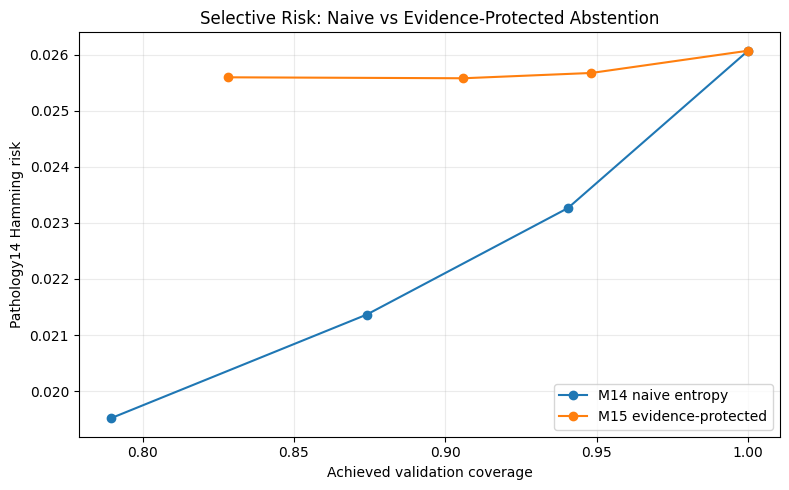

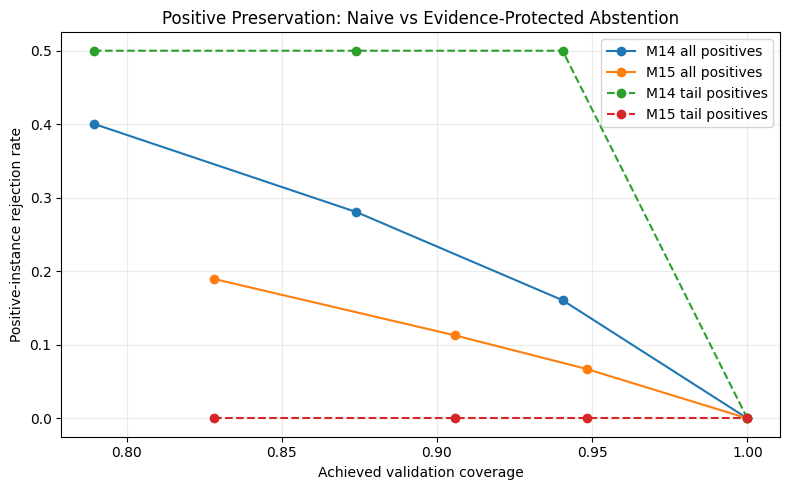

In [15]:
# ============================================================
# 16. Scientific plots
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

plot_df = (
    m14_vs_m15
    .sort_values(
        "M15_achieved_coverage"
    )
)

ax.plot(
    plot_df[
        "M14_achieved_coverage"
    ],
    plot_df[
        "M14_hamming_risk"
    ],
    marker="o",
    label=
        "M14 naive entropy",
)

ax.plot(
    plot_df[
        "M15_achieved_coverage"
    ],
    plot_df[
        "M15_hamming_risk"
    ],
    marker="o",
    label=
        "M15 evidence-protected",
)

ax.set_xlabel(
    "Achieved validation coverage"
)
ax.set_ylabel(
    "Pathology14 Hamming risk"
)
ax.set_title(
    "Selective Risk: Naive vs Evidence-Protected Abstention"
)
ax.grid(
    alpha=0.25
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "M14_vs_M15_hamming_risk.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    plot_df[
        "M14_achieved_coverage"
    ],
    plot_df[
        "M14_all_positive_rejection"
    ],
    marker="o",
    label=
        "M14 all positives",
)

ax.plot(
    plot_df[
        "M15_achieved_coverage"
    ],
    plot_df[
        "M15_all_positive_rejection"
    ],
    marker="o",
    label=
        "M15 all positives",
)

ax.plot(
    plot_df[
        "M14_achieved_coverage"
    ],
    plot_df[
        "M14_tail_positive_rejection"
    ],
    marker="o",
    linestyle="--",
    label=
        "M14 tail positives",
)

ax.plot(
    plot_df[
        "M15_achieved_coverage"
    ],
    plot_df[
        "M15_tail_positive_rejection"
    ],
    marker="o",
    linestyle="--",
    label=
        "M15 tail positives",
)

ax.set_xlabel(
    "Achieved validation coverage"
)
ax.set_ylabel(
    "Positive-instance rejection rate"
)
ax.set_title(
    "Positive Preservation: Naive vs Evidence-Protected Abstention"
)
ax.grid(
    alpha=0.25
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "M14_vs_M15_positive_rejection.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [16]:
# ============================================================
# 17. Save frozen M15 policy + README
# ============================================================
policy_threshold_records = []

for row in policy_thresholds.itertuples(
    index=False
):
    entropy_threshold = (
        row.entropy_threshold_unprotected
    )

    if np.isposinf(
        entropy_threshold
    ):
        entropy_json = None
        entropy_state = (
            "accept_all"
        )
    elif np.isneginf(
        entropy_threshold
    ):
        entropy_json = None
        entropy_state = (
            "accept_protected_only"
        )
    else:
        entropy_json = float(
            entropy_threshold
        )
        entropy_state = (
            "finite_threshold"
        )

    policy_threshold_records.append({
        "target_coverage":
            float(
                row.target_coverage
            ),
        "entropy_threshold":
            entropy_json,
        "entropy_threshold_state":
            entropy_state,
        "calibration_achieved_coverage":
            float(
                row.calibration_achieved_coverage
            ),
    })

policy = {
    "experiment_id":
        EXPERIMENT_ID,
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "calibration_experiment_id":
        CALIBRATION_EXPERIMENT_ID,
    "naive_selective_baseline_experiment_id":
        NAIVE_SELECTIVE_EXPERIMENT_ID,
    "temperature":
        TEMPERATURE,
    "primary_uncertainty":
        PRIMARY_UNCERTAINTY,
    "abnormal_evidence":
        "maximum calibrated probability across 14 pathology outputs",
    "protection_quantile_calibration":
        PROTECTION_QUANTILE,
    "protection_threshold":
        PROTECTION_THRESHOLD,
    "protection_rule":
        "always accept if max calibrated pathology probability >= protection_threshold",
    "target_coverages":
        TARGET_COVERAGES,
    "entropy_threshold_source":
        "calibration_split_unprotected_images_only",
    "thresholds":
        policy_threshold_records,
    "ground_truth_used_to_define_policy":
        False,
    "rarity_groups_used_to_define_policy":
        False,
    "rarity_groups_used_for_posthoc_audit_only":
        True,
    "validation_used_for_policy_fitting":
        False,
    "official_test_used":
        False,
    "split_manifest_sha256":
        EXPECTED_SPLIT_MANIFEST_SHA256,
}

with open(
    OUTPUT_DIR
    / "evidence_protected_selective_policy.json",
    "w",
) as f:
    json.dump(
        policy,
        f,
        indent=2,
    )

coverage_80 = (
    m15_summary.loc[
        np.isclose(
            m15_summary[
                "target_coverage"
            ],
            0.80,
        )
    ]
    .iloc[
        0
    ]
)

naive_80 = (
    m14_summary.loc[
        np.isclose(
            m14_summary[
                "target_coverage"
            ],
            0.80,
        )
    ]
    .iloc[
        0
    ]
)

readme_lines = [
    "Pediatric Chest X-ray — M15 Evidence-Protected Selective Prediction",
    "=" * 78,
    "",
    "POLICY",
    "- Primary uncertainty: calibrated mean pathology entropy.",
    "- Abnormal evidence: maximum calibrated pathology probability.",
    f"- Protection threshold: calibration {PROTECTION_QUANTILE:.0%} quantile = {PROTECTION_THRESHOLD:.8f}",
    "- Protected cases are always accepted.",
    "- Entropy thresholds are fit on unprotected calibration images only.",
    "- True labels are NOT used to define the protection policy.",
    "",
    "VALIDATION PROTECTION",
    f"- Protected validation fraction: {val_protected.mean():.6f}",
    "",
    "TARGET 80% COMPARISON",
    f"- M14 naive achieved coverage: {naive_80['achieved_coverage']:.6f}",
    f"- M15 protected achieved coverage: {coverage_80['achieved_coverage']:.6f}",
    f"- M14 Hamming risk: {naive_80['hamming_risk']:.6f}",
    f"- M15 Hamming risk: {coverage_80['hamming_risk']:.6f}",
    f"- M14 all-positive rejection: {naive_80['all_positive_instance_rejection_rate']:.6f}",
    f"- M15 all-positive rejection: {coverage_80['all_positive_instance_rejection_rate']:.6f}",
    f"- M14 tail-positive rejection: {naive_80['tail_positive_instance_rejection_rate']:.6f}",
    f"- M15 tail-positive rejection: {coverage_80['tail_positive_instance_rejection_rate']:.6f}",
    "",
    "INTERPRETATION",
    "- 12C tests the tradeoff between generic risk reduction and pathology-positive preservation.",
    "- It is not acceptable to call a policy safer only because it abstains on abnormal/rare positive cases.",
    "- Tail metrics remain statistically unstable when the number of positives is tiny.",
    "",
    "SAFETY",
    "- Validation used to fit policy: NO",
    "- Ground-truth labels used to define accept/reject rule: NO",
    "- Tail rarity labels used to define accept/reject rule: NO",
    "- Official test used: NO",
]

README_RESULTS = "\n".join(
    readme_lines
)

print(
    README_RESULTS
)

with open(
    OUTPUT_DIR
    / "README_RESULTS.txt",
    "w",
) as f:
    f.write(
        README_RESULTS
    )


Pediatric Chest X-ray — M15 Evidence-Protected Selective Prediction

POLICY
- Primary uncertainty: calibrated mean pathology entropy.
- Abnormal evidence: maximum calibrated pathology probability.
- Protection threshold: calibration 80% quantile = 0.25255560
- Protected cases are always accepted.
- Entropy thresholds are fit on unprotected calibration images only.
- True labels are NOT used to define the protection policy.

VALIDATION PROTECTION
- Protected validation fraction: 0.212252

TARGET 80% COMPARISON
- M14 naive achieved coverage: 0.789474
- M15 protected achieved coverage: 0.828300
- M14 Hamming risk: 0.019516
- M15 Hamming risk: 0.025595
- M14 all-positive rejection: 0.400480
- M15 all-positive rejection: 0.189448
- M14 tail-positive rejection: 0.500000
- M15 tail-positive rejection: 0.000000

INTERPRETATION
- 12C tests the tradeoff between generic risk reduction and pathology-positive preservation.
- It is not acceptable to call a policy safer only because it abstains on ab

In [17]:
# ============================================================
# 18. Final integrity gate
# ============================================================
coverage_monotonic = bool(
    m15_summary.sort_values(
        "target_coverage"
    )[
        "achieved_coverage"
    ]
    .is_monotonic_increasing
)

threshold_count_ok = (
    len(
        policy_thresholds
    )
    == len(
        TARGET_COVERAGES
    )
)

protected_always_accepted = True

for target, accepted in acceptance_columns.items():
    if (
        not accepted[
            val_protected
        ].all()
    ):
        protected_always_accepted = False
        break

metrics_finite = bool(
    np.isfinite(
        m15_summary[
            [
                "hamming_risk",
                "mean_image_brier_risk",
                "pathology14_macro_AUPRC",
                "pathology14_macro_F1_at_0.5",
                "all_positive_instance_rejection_rate",
                "tail_positive_instance_rejection_rate",
            ]
        ].to_numpy(
            dtype=float
        )
    ).all()
)

checks = pd.DataFrame([
    {
        "check":
            "M13 calibrator verified",
        "passed":
            scaler.get(
                "experiment_id"
            )
            == CALIBRATION_EXPERIMENT_ID,
    },
    {
        "check":
            "M14 naive baseline verified",
        "passed":
            m14_policy.get(
                "experiment_id"
            )
            == NAIVE_SELECTIVE_EXPERIMENT_ID,
    },
    {
        "check":
            "Frozen split hash verified",
        "passed":
            scaler.get(
                "split_manifest_sha256"
            )
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check":
            "Calibration rows = 1,161",
        "passed":
            len(
                calibration_table
            )
            == 1161,
    },
    {
        "check":
            "Validation rows = 1,159",
        "passed":
            len(
                validation_table
            )
            == 1159,
    },
    {
        "check":
            "M13 probabilities reproduce from logits/T",
        "passed":
            max(
                cal_repro,
                val_repro,
            )
            <= 1e-6,
    },
    {
        "check":
            "Rarity labels verified",
        "passed":
            set(
                rarity_groups[
                    "label"
                ]
            )
            == set(
                PATHOLOGY_COLUMNS
            ),
    },
    {
        "check":
            "Protection threshold finite",
        "passed":
            np.isfinite(
                PROTECTION_THRESHOLD
            ),
    },
    {
        "check":
            "Protection policy uses no ground-truth labels",
        "passed":
            True,
    },
    {
        "check":
            "Rarity groups used for audit only",
        "passed":
            True,
    },
    {
        "check":
            "Protected validation cases always accepted",
        "passed":
            protected_always_accepted,
    },
    {
        "check":
            "All target coverage policies exported",
        "passed":
            threshold_count_ok,
    },
    {
        "check":
            "Achieved validation coverage monotonic",
        "passed":
            coverage_monotonic,
    },
    {
        "check":
            "Selective metrics finite",
        "passed":
            metrics_finite,
    },
    {
        "check":
            "Validation not used to fit policy thresholds",
        "passed":
            True,
    },
    {
        "check":
            "Official test not used",
        "passed":
            True,
    },
])

checks[
    "status"
] = checks[
    "passed"
].map({
    True:
        "PASS",
    False:
        "REVIEW",
})

display(
    checks
)

checks.to_csv(
    OUTPUT_DIR
    / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks[
        "passed"
    ].all()
    else "REVIEW"
)

print(
    "\nM15 EVIDENCE-PROTECTED SELECTIVE PREDICTION FINAL STATUS:",
    FINAL_STATUS,
)

if (
    FINAL_STATUS
    == "PASS"
):
    print(
        "✅ M15 EVIDENCE-PROTECTED SELECTIVE ANALYSIS COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE MAKING THE FINAL SELECTIVE-PREDICTION DECISION"
    )


,check,passed,status
0,M13 calibrator verified,True,PASS
1,M14 naive baseline verified,True,PASS
2,Frozen split hash verified,True,PASS
3,"Calibration rows = 1,161",True,PASS
4,"Validation rows = 1,159",True,PASS
5,M13 probabilities reproduce from logits/T,True,PASS
6,Rarity labels verified,True,PASS
7,Protection threshold finite,True,PASS
8,Protection policy uses no ground-truth labels,True,PASS
9,Rarity groups used for audit only,True,PASS



M15 EVIDENCE-PROTECTED SELECTIVE PREDICTION FINAL STATUS: PASS
✅ M15 EVIDENCE-PROTECTED SELECTIVE ANALYSIS COMPLETED SUCCESSFULLY


# 19. Export rule

The ZIP includes:

- frozen evidence-protected selective policy;
- calibration-derived protection and entropy thresholds;
- validation selective metrics;
- per-class retained metrics;
- Head/Middle/Tail rejection audit;
- direct M14-vs-M15 comparison;
- risk-vs-positive-preservation tradeoff table;
- per-image validation protection/acceptance flags;
- figures;
- integrity checks.

The ZIP contains no DICOM or official-test output.


In [18]:
# ============================================================
# 20. Package complete M15 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "M15_EvidenceProtectedSelectivePrediction_Seed42_All_Outputs.zip"
)

if (
    ZIP_FILE.exists()
):
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob(
        "*"
    )
    if p.is_file()
)

if (
    not source_files
):
    raise RuntimeError(
        "No M15 output files found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if (
        p.suffix.lower()
        in blocked_extensions
    ):
        raise RuntimeError(
            "STOP: restricted/raw file detected: "
            + str(
                p
            )
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=
        zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        arcname = (
            Path(
                EXPERIMENT_ID
            )
            / p.relative_to(
                OUTPUT_DIR
            )
        )

        zf.write(
            p,
            arcname=str(
                arcname
            ),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    corrupt_entry = (
        zf.testzip()
    )
    archive_names = (
        zf.namelist()
    )

if (
    corrupt_entry
    is not None
):
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(
            corrupt_entry
        )
    )

required_outputs = [
    "evidence_protected_selective_policy.json",
    "evidence_protected_calibration_thresholds.csv",
    "validation_evidence_protected_selective_summary.csv",
    "validation_evidence_protected_per_class.csv",
    "validation_evidence_protected_rarity_rejection.csv",
    "M14_naive_vs_M15_evidence_protected.csv",
    "M15_risk_positive_preservation_tradeoff.csv",
    "validation_evidence_protection_and_acceptance.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

missing_outputs = [
    name
    for name in required_outputs
    if (
        not any(
            x.endswith(
                "/"
                + name
            )
            for x in archive_names
        )
    )
]

if (
    missing_outputs
):
    raise RuntimeError(
        "ZIP missing required files: "
        + str(
            missing_outputs
        )
    )

print(
    "✅ M15 COMPLETE OUTPUT ZIP CREATED"
)
print(
    "File:",
    ZIP_FILE,
)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print(
    "ZIP integrity: PASS"
)
print(
    "Official test outputs included: NO"
)
print(
    "Raw X-ray/DICOM files included: NO"
)


✅ M15 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M15_EvidenceProtectedSelectivePrediction_Seed42_All_Outputs.zip
ZIP size: 0.27 MB
ZIP integrity: PASS
Official test outputs included: NO
Raw X-ray/DICOM files included: NO


## What to send back

After the run finishes, send:

`M15_EvidenceProtectedSelectivePrediction_Seed42_All_Outputs.zip`

I will compare 12C directly against 12B and answer:

- How much positive rejection was recovered?
- Did Tail/Middle rejection improve?
- How much Hamming/Brier risk benefit was sacrificed?
- Did achieved coverage shift because of the protection rule?
- Does any coverage point provide a defensible risk–preservation tradeoff?

### Final decision after 12C

If 12C substantially preserves pathology-positive cases while retaining useful risk reduction, we can keep it as the safer selective-policy candidate.

If positive preservation comes only by giving up nearly all selective-risk benefit, we stop policy redesign and report the tradeoff transparently rather than forcing an abstention claim.
